In [4]:
#Importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [5]:
#Data collection and pre processing
titanic_data = pd.read_csv('train.csv')
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
titanic_data.shape #rows and col in our Dataset

(891, 12)

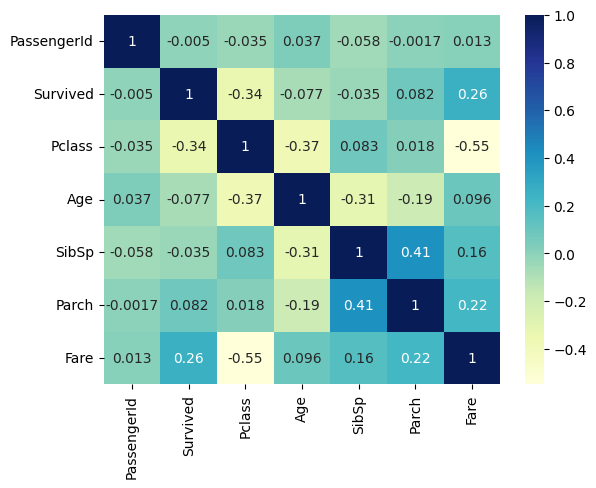

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Keep only the numeric columns
numeric_data = titanic_data.select_dtypes(include=['number'])

# 2. Now plot the heatmap
sns.heatmap(numeric_data.corr(), cmap="YlGnBu", annot=True)
plt.show()


In [8]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
# check no. of missing values in each col
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


I noticed there are missing values in 'Age', 'Cabin', and a few in 'Embarked'. Missing data can confuse machine learning models because they expect complete information. So, I'm going to handle these missing values to make sure the model can learn properly.

Here the 'cabin' col is to be dropped and removed compleatly as most of the values are missing, we cant find mean to fill in as most data points are missing.

In [10]:
# Handeling the missing values

titanic_data = titanic_data.drop(columns='Cabin')


In [11]:
from sklearn.impute import SimpleImputer

age_imputer = SimpleImputer(strategy='mean')
titanic_data['Age'] = age_imputer.fit_transform(titanic_data[['Age']]).ravel()

embarked_imputer = SimpleImputer(strategy='most_frequent')
titanic_data['Embarked'] = embarked_imputer.fit_transform(titanic_data[['Embarked']]).ravel()



In [12]:
titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True)

<ipython-input-12-bc2b444396f9>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True)


In [13]:
titanic_data.describe() # statstical measures for each col

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<ipython-input-14-0bc9f2003398>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=titanic_data, palette=['red', 'green'])


,count
Survived,
0,549
1,342


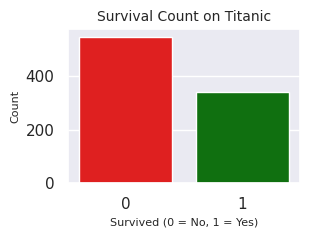

In [14]:
# Data Visualization

sns.set()
plt.figure(figsize=(3, 2))
plt.title('Survival Count on Titanic', fontsize=10)
plt.xlabel('Survived (0 = No, 1 = Yes)', fontsize=8)
plt.ylabel('Count', fontsize=8)
sns.countplot(x='Survived', data=titanic_data, palette=['red', 'green'])
titanic_data['Survived'].value_counts()


<ipython-input-15-ed5d8da4c9f1>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=titanic_data, palette=['blue', 'pink'])


,count
Sex,
male,577
female,314


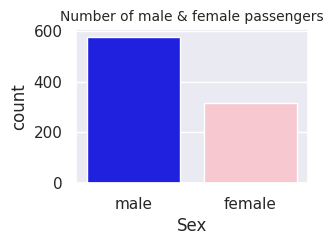

In [15]:
plt.figure(figsize=(3, 2))
plt.title('Number of male & female passengers', fontsize=10)
sns.countplot(x='Sex', data=titanic_data, palette=['blue', 'pink'])
titanic_data['Sex'].value_counts()

<Axes: xlabel='Sex', ylabel='count'>

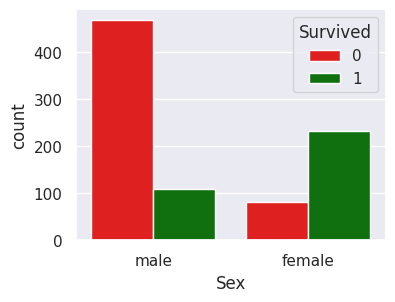

In [16]:
# no. of people survived based on gender

plt.figure(figsize=(4, 3))
sns.countplot(x='Sex', hue='Survived', data=titanic_data, palette=['red', 'green'])

<Axes: xlabel='Pclass', ylabel='count'>

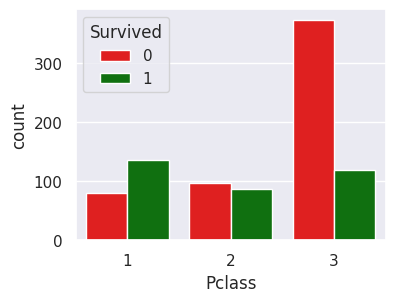

In [17]:
# No. of people survived based on pclass

plt.figure(figsize=(4, 3))
sns.countplot(x='Pclass', hue='Survived', data=titanic_data, palette=['red', 'green'])


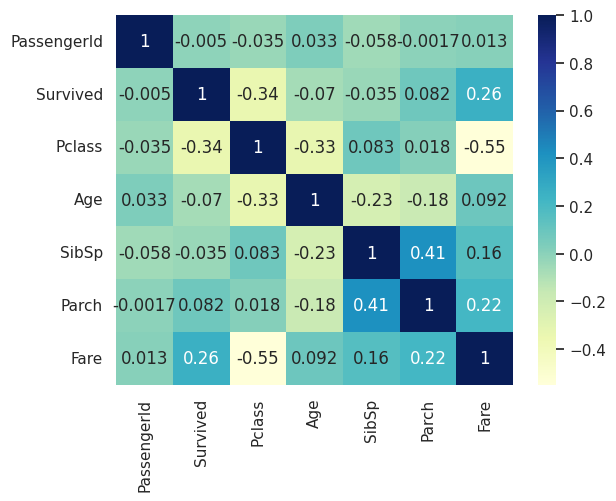

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Keep only the numeric columns
numeric_data = titanic_data.select_dtypes(include=['number'])

# 2. Now plot the heatmap
sns.heatmap(numeric_data.corr(), cmap="YlGnBu", annot=True)
plt.show()

In [19]:
# encoding the catogorical data
titanic_data.replace({'Sex':{'male':0,'female':1}, 'Embarked':{'S':0,'C':1,'Q':2}}, inplace=True)

<ipython-input-19-b0a48d2e8f40>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic_data.replace({'Sex':{'male':0,'female':1}, 'Embarked':{'S':0,'C':1,'Q':2}}, inplace=True)


In [20]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0


In [21]:
# seperate featurs and target
X = titanic_data.drop(columns = ['PassengerId','Name','Ticket','Survived'],axis=1)
Y = titanic_data['Survived']

In [22]:
print(X)

     Pclass  Sex        Age  SibSp  Parch     Fare  Embarked
0         3    0  22.000000      1      0   7.2500         0
1         1    1  38.000000      1      0  71.2833         1
2         3    1  26.000000      0      0   7.9250         0
3         1    1  35.000000      1      0  53.1000         0
4         3    0  35.000000      0      0   8.0500         0
..      ...  ...        ...    ...    ...      ...       ...
886       2    0  27.000000      0      0  13.0000         0
887       1    1  19.000000      0      0  30.0000         0
888       3    1  29.699118      1      2  23.4500         0
889       1    0  26.000000      0      0  30.0000         1
890       3    0  32.000000      0      0   7.7500         2

[891 rows x 7 columns]


In [23]:
print(Y)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=2)

In [25]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0


In [26]:
# Model Training

models = {
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Support Vector Machine': SVC(),
    'Logistic Regression': LogisticRegression()
}



In [27]:
# Define and train models
rf = RandomForestClassifier()
rf.fit(X_train, Y_train)

gb = GradientBoostingClassifier()
gb.fit(X_train, Y_train)

svm = SVC()
svm.fit(X_train, Y_train)

lr = LogisticRegression()
lr.fit(X_train, Y_train)

# Predictions
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)
svm_pred = svm.predict(X_test)
lr_pred = lr.predict(X_test)

# Accuracy
print('Random Forest Test Accuracy:', accuracy_score(Y_test, rf_pred))
print('Gradient Boosting Test Accuracy:', accuracy_score(Y_test, gb_pred))
print('Support Vector Machine Test Accuracy:', accuracy_score(Y_test, svm_pred))
print('Logistic Regression Test Accuracy:', accuracy_score(Y_test, lr_pred))


Random Forest Test Accuracy: 0.8044692737430168
Gradient Boosting Test Accuracy: 0.7932960893854749
Support Vector Machine Test Accuracy: 0.6368715083798883
Logistic Regression Test Accuracy: 0.7821229050279329


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
